# How big is the invertibility radius the IFT actually promises?

Notebook 13 showed that **central differences (CD) reports `min(Jdet) = +0.40`** on the bowtie even though the cell is geometrically folded — the 2-triangle check (and the bilinear $J(s,t)$ analysis in section 6 of that notebook) catches it. CD's positive Jdet is a true statement about *something* — but what?

The implicit function theorem gives a precise answer. If $DF(x_0)$ is invertible, then $F$ is a local diffeomorphism on *some* open ball $B_r(x_0)$. The radius $r$ is **not arbitrary**: a quantitative version of the IFT bounds it in terms of how well-conditioned $DF$ is and how fast it changes. So the question becomes:

> **At the bowtie pixel, where $J_{\rm CD} = +0.40 > 0$, what radius $r$ does the IFT actually promise — and does that radius reach the cell boundary?**

The hypothesis: at every fold pixel, $r$ collapses well below 1 px, even when $J_{\rm CD}$ stays positive. The cell folds because the IFT-guaranteed neighbourhood of invertibility is *smaller than the cell*. The two formulations explored below should both confirm this — and the radius map should match exactly the cells where the 2-tri check fires.


## The puzzle, restated

For the bowtie field on a 7×7 grid (`dx[3,3] = +1.2`, `dx[3,4] = −1.2`, everything else zero):

| metric | value | interpretation |
|---|---:|---|
| $J_{\rm CD}(3, 3)$ | $+0.40$ | "locally invertible" per IFT premise |
| $\min(T_1, T_2)$ on cell $(3, 3)$ | $-0.70$ | **cell is folded** (geometric truth) |
| bilinear $J(s, t)$ on cell $(3, 3)$ | $-1.4 \le J \le +1.0$ | fold occupies $\sim 58\%$ of the cell |

Both signals are correct. CD is reporting that the *linearisation at the lattice point* is orientation-preserving with $\sigma_{\min}(DF) = 0.4$. 2-tri / bilinear is reporting that the *deformed quad* self-intersects. The IFT bridges them: it says CD's linearisation is enough for invertibility — but only on a ball whose radius depends on how violently $DF$ changes near the pixel. A spike in $D^2\varphi$ shrinks the ball.

That spike is exactly what the bowtie does (`dx[3,3] = +1.2`, `dx[3,4] = −1.2` produces a $-3.6$ second-difference in $dx$ across $x$). So the IFT *does* say something at the bowtie pixel — it just says "$r$ is sub-pixel," which means CD's locally-invertible neighbourhood doesn't reach the cell edge, and the cell is free to fold without contradicting the theorem.


## Two ways to compute $r$

### A. Lipschitz IFT bound (theoretical, conservative)

Quantitative inverse function theorem. If $DF$ is $L$-Lipschitz on a neighbourhood of $x_0$ and $\sigma_{\min}(DF(x_0)) = \alpha$, then $F$ is a bijection on $B_r(x_0)$ for any

$$
r \;<\; \frac{\sigma_{\min}(DF(x_0))}{L_{\rm local}(x_0)},
\qquad
L_{\rm local}(x_0) \;=\; \sup_{x \,\text{near}\, x_0} \| D^2 \varphi(x) \|.
$$

$\sigma_{\min}(DF)$ comes from the CD-Jacobian SVD. $L_{\rm local}$ is estimated by the Frobenius norm of the second-order central differences of $\varphi$ in a neighbourhood. This is the *honest* bound the theorem actually gives — and because Frobenius bounds the operator norm of the third-order tensor $D^2\varphi$, the resulting $r$ is conservative (smaller than the true invertibility radius). If even this loose bound predicts sub-pixel $r$, the cell can fold.

### B. Exact bilinear radius (geometric, tight for the bilinear model)

Image-grid deformation fields are usually understood as bilinear interpolants of the lattice values. Notebook 13 §6 computed the closed-form bilinear $J(s, t)$ in cell $(3, 3)$. Per cell, $J(s, t)$ is a quadratic polynomial in $(s, t) \in [0, 1]^2$, and the fold region is exactly $\{J \le 0\}$. The **exact invertibility radius** at any point $x$ is the Euclidean distance from $x$ to the nearest point of $\{J \le 0\}$ across all cells:

$$
r_{\rm exact}(x) \;=\; \inf \big\{\, \| x - y \| \;:\; J_{\rm bilinear}(y) \le 0 \,\big\}.
$$

This is *not a bound* — it's the radius itself, for the bilinear model. We compute it by densely sampling $J$ inside every cell and finding the nearest sub-zero sample to each pixel.

### Where each one gets its data from

The two formulations use *different inputs*, so they give an independent cross-check rather than two views of the same numbers. The same split separates CD from 2-tri:

| method | data input | interpolation model | output |
|---|---|---|---|
| `J_CD` (notebook 13) | neighbour-differences at lattice vertices | none | scalar / pixel |
| **IFT Lipschitz bound** | CD Jacobian + CD second-differences (all neighbour-differences) | none | scalar / pixel |
| **2-tri** (notebook 13) | 4 corner displacements per cell | piecewise-linear (cell split into 2 triangles) | 2 scalars / cell |
| **Exact bilinear radius** | 4 corner displacements per cell — *same input as 2-tri* | bilinear quadric over the unit square | scalar field / cell |

So the IFT bound is *purely CD-derived* — it's an independent confirmation from the lattice-vertex side. The exact bilinear radius is *purely cell-corner-derived* — it shares its input with the 2-tri check, just with a smoother interpolation model (bilinear quadric instead of two flat triangles). The two are different checks with different premises, and they should agree on *which* cells fold (they do) while disagreeing on the *numerical* size of $r$ (the IFT bound is loose; the bilinear radius is tight).

### What we expect

For a pixel that 2-tri flags as folded, $r_{\rm exact}$ should be $\sim 0$ (the pixel sits at a fold corner, since adjacent cells already have $J_{\rm bilinear} \le 0$ at it). For a non-folded but adjacent pixel, both $r_{\rm IFT}$ and $r_{\rm exact}$ should be sub-pixel. For pixels far from any fold, both radii should be well above 1 px.

The visual claim of this notebook: the small-radius circles align with the outlined fold cells, regardless of which side (CD or cell-corner) the radius was derived from. The IFT and the 2-tri check tell a single coherent story.


In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon

from dvfopt import jacobian_det2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d


In [2]:
# ---------- Lipschitz IFT bound ----------

def deformation_jacobian_cd(phi):
    """Per-pixel deformation Jacobian DF(x) = I + Dphi(x), shape (H, W, 2, 2).

    Uses np.gradient (central differences in the interior, one-sided at the edges)
    to match dvfopt.jacobian.numpy_jdet's stencil.
    """
    H, W = phi.shape[-2:]
    dy, dx = phi[0], phi[1]
    DF = np.empty((H, W, 2, 2))
    DF[..., 0, 0] = 1.0 + np.gradient(dy, axis=0)  # 1 + d(dy)/dy
    DF[..., 0, 1] = np.gradient(dy, axis=1)        #     d(dy)/dx
    DF[..., 1, 0] = np.gradient(dx, axis=0)        #     d(dx)/dy
    DF[..., 1, 1] = 1.0 + np.gradient(dx, axis=1)  # 1 + d(dx)/dx
    return DF


def sigma_min_field(DF):
    """Smallest singular value of DF at every pixel, shape (H, W)."""
    H, W = DF.shape[:2]
    out = np.empty((H, W))
    for i in range(H):
        for j in range(W):
            out[i, j] = np.linalg.svd(DF[i, j], compute_uv=False).min()
    return out


def second_derivative_norm(phi):
    """Frobenius-norm bound on D^2 phi at every pixel using 3-point stencils.

    For an interior pixel, the 6 distinct second derivatives (yy, xx, yx for each
    of dy, dx) are computed via the standard central-difference stencils:
        d^2 f / dy^2 = f[y+1, x] - 2 f[y, x] + f[y-1, x]
        d^2 f / dx^2 = f[y, x+1] - 2 f[y, x] + f[y, x-1]
        d^2 f / dy dx = (f[y+1,x+1] - f[y+1,x-1] - f[y-1,x+1] + f[y-1,x-1]) / 4

    Boundary pixels report 0 (no Lipschitz contribution detectable).
    """
    H, W = phi.shape[-2:]
    dy, dx = phi[0], phi[1]
    L2 = np.zeros((H, W))
    for f in (dy, dx):
        d2_yy = np.zeros_like(f); d2_xx = np.zeros_like(f); d2_yx = np.zeros_like(f)
        d2_yy[1:-1, :] = f[2:, :] - 2.0 * f[1:-1, :] + f[:-2, :]
        d2_xx[:, 1:-1] = f[:, 2:] - 2.0 * f[:, 1:-1] + f[:, :-2]
        d2_yx[1:-1, 1:-1] = 0.25 * (f[2:, 2:] - f[2:, :-2] - f[:-2, 2:] + f[:-2, :-2])
        # Frobenius for the symmetric 2x2 second-derivative matrix per component:
        # off-diagonals appear twice in the sum (yx and xy), hence factor 2.
        L2 += d2_yy ** 2 + d2_xx ** 2 + 2.0 * d2_yx ** 2
    return np.sqrt(L2)


def lipschitz_constant_local(phi, neighborhood=1):
    """Local Lipschitz constant of DF, taking sup of ||D^2 phi|| over a window.

    For each pixel, take the max Frobenius norm in a (2*neighborhood+1)^2 window.
    neighborhood=0 means use the pixel value directly. neighborhood=1 covers the
    immediate 3x3 neighborhood.
    """
    L_pointwise = second_derivative_norm(phi)
    if neighborhood == 0:
        return L_pointwise
    H, W = L_pointwise.shape
    out = np.zeros_like(L_pointwise)
    for py in range(H):
        for px in range(W):
            ymin = max(0, py - neighborhood); ymax = min(H, py + neighborhood + 1)
            xmin = max(0, px - neighborhood); xmax = min(W, px + neighborhood + 1)
            out[py, px] = L_pointwise[ymin:ymax, xmin:xmax].max()
    return out


def ift_radius_field(phi, neighborhood=1, eps=1e-12):
    """Quantitative-IFT radius r = sigma_min(DF) / L_local at every pixel.

    Returns NaN where J_CD <= 0 (IFT premise fails) and +inf where L = 0
    (locally affine, IFT gives no upper bound on r).
    """
    DF = deformation_jacobian_cd(phi)
    sig = sigma_min_field(DF)
    L = lipschitz_constant_local(phi, neighborhood=neighborhood)
    jdet = np.squeeze(jacobian_det2D(phi))
    r = np.where(L > eps, sig / np.maximum(L, eps), np.inf)
    r = np.where(jdet > 0, r, np.nan)
    return r, sig, L, jdet


In [3]:
# ---------- Exact bilinear radius ----------

def bilinear_J_in_cell(phi, cy, cx, S=41):
    """Bilinear J(s, t) over cell (cy, cx). Returns (S, S) arrays.

    J(s, t) is the determinant of the deformation Jacobian under bilinear
    interpolation of the four corner displacements. Y_phys, X_phys are the
    *reference-frame* (undeformed) coordinates of each (s, t) sample, so that
    radius computations are done in pixel-grid space.
    """
    dy_TL, dx_TL = phi[0, cy,     cx],     phi[1, cy,     cx]
    dy_TR, dx_TR = phi[0, cy,     cx + 1], phi[1, cy,     cx + 1]
    dy_BL, dx_BL = phi[0, cy + 1, cx],     phi[1, cy + 1, cx]
    dy_BR, dx_BR = phi[0, cy + 1, cx + 1], phi[1, cy + 1, cx + 1]

    ss = np.linspace(0, 1, S); tt = np.linspace(0, 1, S)
    SS, TT = np.meshgrid(ss, tt, indexing='ij')

    ddy_ds = -(1 - TT) * dy_TL - TT * dy_TR + (1 - TT) * dy_BL + TT * dy_BR
    ddy_dt = -(1 - SS) * dy_TL + (1 - SS) * dy_TR - SS * dy_BL + SS * dy_BR
    ddx_ds = -(1 - TT) * dx_TL - TT * dx_TR + (1 - TT) * dx_BL + TT * dx_BR
    ddx_dt = -(1 - SS) * dx_TL + (1 - SS) * dx_TR - SS * dx_BL + SS * dx_BR

    J = (1 + ddy_ds) * (1 + ddx_dt) - ddy_dt * ddx_ds
    Y_phys = cy + SS
    X_phys = cx + TT
    return SS, TT, J, Y_phys, X_phys


def exact_bilinear_radius_field(phi, S=41):
    """Per-pixel distance to the nearest bilinear-J <= 0 sample, in pixel units.

    Densely samples J(s, t) on every cell, then for each lattice pixel finds the
    nearest sample with J <= 0. Pixels where no fold exists anywhere on the grid
    return +inf.
    """
    H, W = phi.shape[-2:]
    pys, pxs, pjs = [], [], []
    for cy in range(H - 1):
        for cx in range(W - 1):
            _, _, J, Y, X = bilinear_J_in_cell(phi, cy, cx, S=S)
            pys.append(Y.ravel()); pxs.append(X.ravel()); pjs.append(J.ravel())
    sample_y = np.concatenate(pys)
    sample_x = np.concatenate(pxs)
    sample_J = np.concatenate(pjs)

    fold_mask = sample_J <= 0
    if not fold_mask.any():
        return np.full((H, W), np.inf)

    fold_y = sample_y[fold_mask]
    fold_x = sample_x[fold_mask]
    out = np.empty((H, W))
    for py in range(H):
        for px in range(W):
            d = np.hypot(fold_y - py, fold_x - px)
            out[py, px] = d.min()
    return out


def folded_cells_mask(phi):
    """Boolean (H-1, W-1) array, True for cells flagged folded by the 2-tri check."""
    T1, T2 = _triangle_areas_2d(phi[0], phi[1])
    return (T1 <= 0) | (T2 <= 0)


## Test cases

Three 7×7 fields, all built on the horizontal $\pm a$ pattern from notebooks 02 / 09 / 13. The amplitude $a$ controls fold severity:

| case | $a$ | expected | what to look for |
|---|---:|---|---|
| **sub-fold** | $0.4$ | no fold anywhere | $r$ is comfortably $> 1$ px everywhere — IFT and 2-tri agree the field is safe |
| **bowtie** | $1.2$ | 2 cells fold | $r \to 0$ at the bowtie pixels; IFT bound predicts sub-pixel $r$ on neighbours |
| **severe** | $1.8$ | 2 cells fold worse | $r \to 0$ over a wider region; even cells one step away have $r \ll 1$ |

We use the *same* lattice positions across all three so the figures compare directly.


In [4]:
def make_horizontal_pair(amplitude, H=7, W=7, py=3, px=3):
    """7x7 field with dx[py, px] = +amplitude and dx[py, px+1] = -amplitude."""
    phi = np.zeros((2, H, W))
    phi[1, py, px]     = +amplitude
    phi[1, py, px + 1] = -amplitude
    return phi


CASES = [
    ('sub-fold',  make_horizontal_pair(0.4)),
    ('bowtie',    make_horizontal_pair(1.2)),
    ('severe',    make_horizontal_pair(1.8)),
]

for name, phi in CASES:
    jd = np.squeeze(jacobian_det2D(phi))
    T1, T2 = _triangle_areas_2d(phi[0], phi[1])
    folded = folded_cells_mask(phi)
    print(f'{name:>10s}:  min(J_CD) = {jd.min():+.3f},  '
          f'min(T1, T2) = {min(T1.min(), T2.min()):+.3f},  '
          f'n_folded_cells = {int(folded.sum())}')


  sub-fold:  min(J_CD) = +0.800,  min(T1, T2) = +0.100,  n_folded_cells = 0
    bowtie:  min(J_CD) = +0.400,  min(T1, T2) = -0.700,  n_folded_cells = 2
    severe:  min(J_CD) = +0.100,  min(T1, T2) = -1.300,  n_folded_cells = 2


In [5]:
def _set_grid_extent(ax, H, W):
    """Clamp axis limits to the lattice extent so circles drawn at boundary
    pixels don't extend past the grid frame. y-axis is inverted (image
    convention)."""
    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)


def _set_lattice_extent(ax, H, W):
    """Clamp axis limits to the lattice corner-to-corner extent [0, W-1] x [0, H-1].

    This is tighter than `_set_grid_extent` (which goes to the half-pixel border).
    Used for the coverage panels: cells only exist between integer lattice points,
    so the half-pixel padding is meaningless and any 'uncovered' shading there is
    a visual artefact rather than a real potential-folding zone.
    """
    ax.set_xlim(0, W - 1)
    ax.set_ylim(H - 1, 0)


def _draw_warped_grid(ax, phi, folded, title, *,
                      radius=None, radius_label='', threshold=0.5,
                      max_circle=2.0, hide_inf=True):
    """Deformed lattice with folded cells outlined.

    If ``radius`` is supplied, also draw circles at the *reference* (undeformed)
    lattice positions, so the IFT/exact radius — a reference-frame quantity —
    appears next to the deformed cells whose folding it predicts. The reference
    lattice is drawn underneath as a dotted grey grid so the reader sees both
    coordinate frames at once.
    """
    H, W = phi.shape[-2:]
    yy, xx = np.mgrid[:H, :W]
    gx = xx + phi[1]; gy = yy + phi[0]

    if radius is not None:
        for i in range(H):
            ax.plot(xx[i], yy[i], color='#cccccc', lw=0.5, ls=':', zorder=0)
        for j in range(W):
            ax.plot(xx[:, j], yy[:, j], color='#cccccc', lw=0.5, ls=':', zorder=0)

    for i in range(H):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8, zorder=2)
    for j in range(W):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8, zorder=2)

    for (cy, cx) in np.argwhere(folded):
        px = [gx[cy, cx], gx[cy, cx + 1], gx[cy + 1, cx + 1], gx[cy + 1, cx], gx[cy, cx]]
        py = [gy[cy, cx], gy[cy, cx + 1], gy[cy + 1, cx + 1], gy[cy + 1, cx], gy[cy, cx]]
        ax.plot(px, py, color='#1565c0', lw=2.0, zorder=4)

    if radius is not None:
        for py_idx in range(H):
            for px_idx in range(W):
                r = radius[py_idx, px_idx]
                if np.isnan(r):
                    ax.plot(px_idx, py_idx, marker='x', color='#b71c1c', markersize=10,
                            markeredgewidth=2.0, zorder=5)
                    continue
                if hide_inf and not np.isfinite(r):
                    ax.plot(px_idx, py_idx, '.', color='#43a047', markersize=4, zorder=5)
                    continue
                r_draw = float(min(r, max_circle))
                color = '#43a047' if r >= threshold else '#e53935'
                lw = 1.6 if r >= threshold else 2.0
                ax.add_patch(Circle((px_idx, py_idx), r_draw, fill=False,
                                    edgecolor=color, lw=lw, zorder=3))
                ax.plot(px_idx, py_idx, '.', color='black', markersize=2, zorder=5)

    ax.set_aspect('equal')
    _set_grid_extent(ax, H, W)
    ax.set_xticks([]); ax.set_yticks([])
    if radius_label:
        ax.set_title(f'{title}\n{radius_label}', fontsize=10)
    else:
        ax.set_title(title, fontsize=10)


def _draw_radius_panel(ax, phi, jd_cd, radius, folded, *, title,
                       max_circle=2.0, threshold=0.5, hide_inf=False):
    """CD Jdet heatmap with circles of radius r at each pixel and folded cells outlined."""
    H, W = phi.shape[-2:]
    vmax = max(abs(jd_cd).max(), 1.0)
    ax.imshow(jd_cd, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
              extent=(-0.5, W - 0.5, H - 0.5, -0.5), origin='upper', aspect='equal')

    for py in range(H):
        for px in range(W):
            r = radius[py, px]
            if np.isnan(r):
                ax.plot(px, py, marker='x', color='#b71c1c', markersize=10,
                        markeredgewidth=2.0, zorder=4)
                continue
            if hide_inf and not np.isfinite(r):
                continue
            r_draw = float(min(r, max_circle))
            color = '#43a047' if r >= threshold else '#e53935'
            lw = 1.6 if r >= threshold else 2.0
            ax.add_patch(Circle((px, py), r_draw, fill=False,
                                edgecolor=color, lw=lw, zorder=2))
            ax.plot(px, py, '.', color='black', markersize=2, zorder=5)

    for (cy, cx) in np.argwhere(folded):
        ax.add_patch(Rectangle((cx - 0.5, cy - 0.5), 1, 1, fill=False,
                                edgecolor='#1565c0', lw=2.5, zorder=3))

    _set_grid_extent(ax, H, W)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)


# -------- coverage maps (filled disks; gaps = potential folding) --------

def coverage_mask(phi, radius, resolution=400, max_r=1.0):
    """Boolean (resolution, resolution) mask: True where some pixel's IFT-promised
    ball contains the sample point. NaN-radius pixels (J_CD <= 0, IFT n/a) contribute
    no ball; +inf-radius pixels are capped at ``max_r`` so they show a finite disk.

    The cap matters for the IFT-CD coverage: pixels far from any spike have
    ``L_local = 0`` and hence ``r = +inf`` (the Lipschitz bound is uninformative
    for locally-affine regions). Without a cap, those inf-balls dominate the
    union and the picture would be all-green even when the small sub-pixel disks
    near a fold can't possibly cover the surrounding cell. ``max_r = 1.0`` (the
    cell-spacing) treats well-behaved pixels as covering exactly their own cell,
    which is the right scale at which to ask "does the IFT bound reach across
    the cell?".

    Sampling domain is the *lattice corner-to-corner* extent [0, W-1] x [0, H-1]
    — that is the support of the cells. Outside that extent (in the half-pixel
    border around the lattice) no cells exist, so a "potential folding zone"
    label there would be meaningless.
    """
    H, W = phi.shape[-2:]
    yy_grid = np.linspace(0, H - 1, resolution)
    xx_grid = np.linspace(0, W - 1, resolution)
    YY, XX = np.meshgrid(yy_grid, xx_grid, indexing='ij')
    covered = np.zeros_like(YY, dtype=bool)
    for py in range(H):
        for px in range(W):
            r = radius[py, px]
            if np.isnan(r):
                continue
            if not np.isfinite(r):
                r = max_r
            covered |= ((YY - py) ** 2 + (XX - px) ** 2 <= r ** 2)
    return covered


def _draw_coverage_panel(ax, phi, folded, radius, *, title,
                         resolution=400, max_r=1.0):
    """Filled-disk coverage view: light green where some IFT-ball covers, red where
    no ball reaches (the 'potential folding zone' between balls). Folded cells
    outlined in blue on top. Pixels where IFT is inapplicable (J_CD <= 0) get a
    red 'x' marker.

    The imshow extent is the *lattice* extent [0, W-1] x [0, H-1] (not the
    half-pixel pixel-area extent), so the coloured region is exactly the area
    where cells exist and the half-pixel border around the lattice stays
    background-coloured.
    """
    H, W = phi.shape[-2:]
    covered = coverage_mask(phi, radius, resolution=resolution, max_r=max_r)

    # RGBA overlay: green for covered, red for uncovered, alpha < 1 so the
    # deformed-lattice lines drawn underneath are still visible.
    rgba = np.zeros((covered.shape[0], covered.shape[1], 4))
    rgba[covered]  = [0.27, 0.63, 0.27, 0.28]   # light green, semi-transparent
    rgba[~covered] = [0.90, 0.22, 0.21, 0.55]   # red, more opaque
    ax.imshow(rgba, extent=(0, W - 1, H - 1, 0),
              origin='upper', aspect='equal', interpolation='nearest', zorder=1)

    yy, xx = np.mgrid[:H, :W]
    gx = xx + phi[1]; gy = yy + phi[0]

    # Reference lattice (faded, dotted) under the deformed lattice
    for i in range(H):
        ax.plot(xx[i], yy[i], color='#cccccc', lw=0.5, ls=':', zorder=2)
    for j in range(W):
        ax.plot(xx[:, j], yy[:, j], color='#cccccc', lw=0.5, ls=':', zorder=2)

    for i in range(H):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8, zorder=3)
    for j in range(W):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8, zorder=3)

    for (cy, cx) in np.argwhere(folded):
        px = [gx[cy, cx], gx[cy, cx + 1], gx[cy + 1, cx + 1], gx[cy + 1, cx], gx[cy, cx]]
        py = [gy[cy, cx], gy[cy, cx + 1], gy[cy + 1, cx + 1], gy[cy + 1, cx], gy[cy, cx]]
        ax.plot(px, py, color='#1565c0', lw=2.0, zorder=4)

    for py in range(H):
        for px in range(W):
            r = radius[py, px]
            if np.isnan(r):
                ax.plot(px, py, marker='x', color='#b71c1c', markersize=10,
                        markeredgewidth=2.0, zorder=5)
            else:
                ax.plot(px, py, '.', color='black', markersize=2, zorder=5)

    uncov_frac = float((~covered).mean())
    ax.set_aspect('equal')
    _set_lattice_extent(ax, H, W)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{title}\n{uncov_frac * 100:.1f}% of lattice uncovered',
                 fontsize=10)


def plot_coverage(phi, name, r_ift, r_exact, folded, *,
                  resolution=400, max_r=1.0):
    """Two-panel coverage figure: IFT-CD coverage | exact-bilinear coverage.
    Filled green = invertibility ball reaches here; red = no ball reaches
    (potential folding zone). Folded cells outlined in blue.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), layout='constrained')

    _draw_coverage_panel(axes[0], phi, folded, r_ift,
                         title='(a) IFT-CD coverage  (data: CD)',
                         resolution=resolution, max_r=max_r)
    _draw_coverage_panel(axes[1], phi, folded, r_exact,
                         title='(b) exact bilinear coverage  (data: cell corners)',
                         resolution=resolution, max_r=max_r)

    legend_lines = [
        Rectangle((0, 0), 1, 1, fc=(0.27, 0.63, 0.27, 0.28),
                  ec='none', label='covered (some IFT-ball reaches)'),
        Rectangle((0, 0), 1, 1, fc=(0.90, 0.22, 0.21, 0.55),
                  ec='none', label='uncovered (potential folding zone)'),
        plt.Line2D([0], [0], color='#1565c0', lw=2.5, label='2-tri folded cell'),
        plt.Line2D([0], [0], marker='x', color='#b71c1c', lw=0, markersize=8,
                   markeredgewidth=2, label=r'$J_{\rm CD} \leq 0$ (no ball)'),
        plt.Line2D([0], [0], color='#cccccc', lw=1, ls=':',
                   label='reference lattice'),
    ]
    fig.legend(handles=legend_lines, loc='outside lower center', ncol=5,
               frameon=False, fontsize=9)

    fig.suptitle(f'{name}  -  IFT coverage  (filled disks, inf-r capped at {max_r:.1f} px = '
                 'cell-scale; red = uncovered = potential folding)',
                 fontsize=12)
    plt.show()


# -------- signed-area triangle viewer (the 2-tri test, made geometric) --------

def plot_affected_triangles(phi, name, *, t_threshold=0.05):
    """Render the deformed quads of cells affected by the displacement spike,
    each split along the TR-BL diagonal into two triangles. Fill each triangle
    by the sign of its signed area (green = positive = orientation-preserving,
    red = negative = folded), annotate the value, outline 2-tri folded cells in
    heavy blue. Print a numerical summary table after.

    The figure is the 2-tri test made literal: a cell is flagged folded iff one
    of its triangles has negative signed area, which iff the deformed quad has
    a self-intersecting (bowtie) interior. The triangle areas printed match what
    `_triangle_areas_2d` returns and what the iterative SLSQP solver constrains.

    Auto-zooms to the bounding box of cells where ``T_i`` deviates from the
    undeformed value 0.5 by more than ``t_threshold``.
    """
    H, W = phi.shape[-2:]
    T1, T2 = _triangle_areas_2d(phi[0], phi[1])
    folded = folded_cells_mask(phi)

    interesting = (np.abs(T1 - 0.5) > t_threshold) | (np.abs(T2 - 0.5) > t_threshold)
    if not interesting.any():
        print(f'{name}: no affected cells.')
        return
    ys, xs = np.where(interesting)
    cy_lo = max(0, ys.min() - 1)
    cy_hi = min(H - 1, ys.max() + 2)
    cx_lo = max(0, xs.min() - 1)
    cx_hi = min(W - 1, xs.max() + 2)

    yy_ref, xx_ref = np.mgrid[:H, :W]
    gx = xx_ref + phi[1]; gy = yy_ref + phi[0]

    fig, ax = plt.subplots(figsize=(9, 8.5), layout='constrained')

    # Faded reference lattice in the zoom window
    for i in range(cy_lo, cy_hi + 1):
        ax.plot([cx_lo, cx_hi], [i, i], color='#dddddd', lw=0.5, ls=':', zorder=0)
    for j in range(cx_lo, cx_hi + 1):
        ax.plot([j, j], [cy_lo, cy_hi], color='#dddddd', lw=0.5, ls=':', zorder=0)

    for cy in range(cy_lo, cy_hi):
        for cx in range(cx_lo, cx_hi):
            t1 = float(T1[cy, cx])
            t2 = float(T2[cy, cx])
            tl = (gx[cy,     cx],     gy[cy,     cx])
            tr = (gx[cy,     cx + 1], gy[cy,     cx + 1])
            bl = (gx[cy + 1, cx],     gy[cy + 1, cx])
            br = (gx[cy + 1, cx + 1], gy[cy + 1, cx + 1])

            # T1 covers (TR, BL, BR) — the "lower-right" triangle in the TR-BL split.
            ax.add_patch(Polygon([tr, bl, br],
                                 facecolor=('#43a047' if t1 > 0 else '#e53935'),
                                 alpha=(0.20 if t1 > 0 else 0.55),
                                 edgecolor='#5b7fb5', lw=0.8, zorder=2))
            # T2 covers (TL, BL, TR) — the "upper-left" triangle.
            ax.add_patch(Polygon([tl, bl, tr],
                                 facecolor=('#43a047' if t2 > 0 else '#e53935'),
                                 alpha=(0.20 if t2 > 0 else 0.55),
                                 edgecolor='#5b7fb5', lw=0.8, zorder=2))

            t1_cx = (tr[0] + bl[0] + br[0]) / 3.0
            t1_cy = (tr[1] + bl[1] + br[1]) / 3.0
            t2_cx = (tl[0] + bl[0] + tr[0]) / 3.0
            t2_cy = (tl[1] + bl[1] + tr[1]) / 3.0
            ax.text(t1_cx, t1_cy, f'{t1:+.2f}', ha='center', va='center', fontsize=8,
                    fontweight=('bold' if t1 <= 0 else 'normal'),
                    color=('#b71c1c' if t1 <= 0 else '#1b5e20'), zorder=4)
            ax.text(t2_cx, t2_cy, f'{t2:+.2f}', ha='center', va='center', fontsize=8,
                    fontweight=('bold' if t2 <= 0 else 'normal'),
                    color=('#b71c1c' if t2 <= 0 else '#1b5e20'), zorder=4)

    for (cy, cx) in np.argwhere(folded):
        if cy_lo <= cy < cy_hi and cx_lo <= cx < cx_hi:
            corners_x = [gx[cy, cx], gx[cy, cx + 1], gx[cy + 1, cx + 1], gx[cy + 1, cx], gx[cy, cx]]
            corners_y = [gy[cy, cx], gy[cy, cx + 1], gy[cy + 1, cx + 1], gy[cy + 1, cx], gy[cy, cx]]
            ax.plot(corners_x, corners_y, color='#0d47a1', lw=2.5, zorder=5)

    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_xlim(cx_lo - 0.3, cx_hi + 0.3)
    ax.set_ylim(cy_hi + 0.3, cy_lo - 0.3)
    ax.set_xticks([]); ax.set_yticks([])

    n_folded = int(folded[cy_lo:cy_hi, cx_lo:cx_hi].sum())
    n_neg_t1 = int((T1[cy_lo:cy_hi, cx_lo:cx_hi] <= 0).sum())
    n_neg_t2 = int((T2[cy_lo:cy_hi, cx_lo:cx_hi] <= 0).sum())

    legend_lines = [
        Rectangle((0, 0), 1, 1, fc='#43a047', alpha=0.20, ec='#5b7fb5',
                  label=r'$T_i > 0$  (orientation-preserving)'),
        Rectangle((0, 0), 1, 1, fc='#e53935', alpha=0.55, ec='#5b7fb5',
                  label=r'$T_i \leq 0$  (folded triangle)'),
        plt.Line2D([0], [0], color='#0d47a1', lw=2.5, label='2-tri folded cell'),
        plt.Line2D([0], [0], color='#cccccc', lw=1, ls=':', label='reference lattice'),
    ]
    ax.legend(handles=legend_lines, loc='upper right', fontsize=9, frameon=True)

    fig.suptitle(f'{name}  -  signed area of each deformed triangle (TR-BL split)\n'
                 f'{n_folded} folded cells  -  '
                 f'{n_neg_t1} neg $T_1$, {n_neg_t2} neg $T_2$ in zoom window  -  '
                 'green = positive, red = negative',
                 fontsize=11)
    plt.show()

    print(f'\n{name}  -  affected cells (|T - 0.5| > {t_threshold} on either triangle):')
    print(f'{"cell (cy,cx)":>13s}  {"T1 (TR,BL,BR)":>15s}  {"T2 (TL,BL,TR)":>15s}  '
          f'{"min(T1,T2)":>11s}  {"folded?":>8s}')
    print('-' * 70)
    for cy in range(cy_lo, cy_hi):
        for cx in range(cx_lo, cx_hi):
            t1 = float(T1[cy, cx]); t2 = float(T2[cy, cx])
            if abs(t1 - 0.5) < t_threshold and abs(t2 - 0.5) < t_threshold:
                continue
            f = folded[cy, cx]
            print(f'   ({cy},{cx})       {t1:>+15.4f}  {t2:>+15.4f}  '
                  f'{min(t1, t2):>+11.4f}  {"YES" if f else "no":>8s}')


def plot_case(phi, name, max_circle=2.0, coverage_resolution=400, coverage_max_r=1.0):
    """Renders three figures per case:

    1. **2x2 circles + grids** — rows are circle data source (IFT-CD vs
       exact-bilinear), columns are background (deformed lattice vs CD heatmap).
    2. **1x2 coverage maps** — filled-disk view of the IFT-promised invertibility
       balls. Green = covered, red = uncovered (potential folding zone where the
       balls fail to overlap and reach). Inf-radius pixels (Lipschitz bound
       uninformative on locally-affine regions) are capped at ``coverage_max_r``
       (= 1.0 px = one cell) so they don't subsume the small disks near a fold.
    3. **Signed-area triangle view** — zoom into the affected cells, render each
       deformed quad split along the TR-BL diagonal, fill triangles by sign of
       T1 / T2, annotate the values. Makes the 2-tri test concrete.
    """
    H, W = phi.shape[-2:]
    DF = deformation_jacobian_cd(phi)
    sig = sigma_min_field(DF)
    L = lipschitz_constant_local(phi, neighborhood=1)
    r_ift, _, _, jd_cd = ift_radius_field(phi, neighborhood=1)
    r_exact = exact_bilinear_radius_field(phi, S=41)
    folded = folded_cells_mask(phi)

    finite_ift = r_ift[np.isfinite(r_ift) & ~np.isnan(r_ift)]
    finite_exact = r_exact[np.isfinite(r_exact)]
    min_r_ift_str = f'{finite_ift.min():.3f} px' if finite_ift.size else 'inf'
    min_r_exact_str = (f'{finite_exact.min():.3f} px' if finite_exact.size else 'inf')

    # ---- Figure 1: 2x2 circles + grids ----------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(11, 10.5), layout='constrained')

    _draw_warped_grid(
        axes[0, 0], phi, folded,
        title=f'(a) deformed lattice + IFT-CD circles  (min r = {min_r_ift_str})',
        radius=r_ift,
        radius_label='circles at reference positions; data: CD',
        threshold=0.5, max_circle=max_circle, hide_inf=True,
    )
    _draw_radius_panel(
        axes[0, 1], phi, jd_cd, r_ift, folded,
        title=f'(b) CD Jdet + IFT-CD circles  (min r = {min_r_ift_str})\n'
              f'data: CD,  cap {max_circle:.1f} px',
        max_circle=max_circle, threshold=0.5, hide_inf=True,
    )
    _draw_warped_grid(
        axes[1, 0], phi, folded,
        title=f'(c) deformed lattice + exact-bilinear circles  (min r = {min_r_exact_str})',
        radius=r_exact,
        radius_label='circles at reference positions; data: cell corners',
        threshold=0.5, max_circle=max_circle, hide_inf=True,
    )
    _draw_radius_panel(
        axes[1, 1], phi, jd_cd, r_exact, folded,
        title=f'(d) CD Jdet + exact-bilinear circles  (min r = {min_r_exact_str})\n'
              f'data: cell corners,  cap {max_circle:.1f} px',
        max_circle=max_circle, threshold=0.5, hide_inf=True,
    )

    legend_lines = [
        plt.Line2D([0], [0], color='#43a047', lw=2, label=r'$r \geq 0.5$ px (cell-safe)'),
        plt.Line2D([0], [0], color='#e53935', lw=2, label=r'$r < 0.5$ px (sub-cell)'),
        plt.Line2D([0], [0], marker='x', color='#b71c1c', lw=0, markersize=8,
                   markeredgewidth=2, label=r'$J_{\rm CD} \leq 0$ (IFT n/a)'),
        plt.Line2D([0], [0], color='#1565c0', lw=2.5, label='2-tri folded cell'),
        plt.Line2D([0], [0], color='#cccccc', lw=1, ls=':',
                   label='reference lattice (warped panels)'),
    ]
    fig.legend(handles=legend_lines, loc='outside lower center', ncol=5,
               frameon=False, fontsize=9)

    fig.suptitle(f'{name}  -  IFT-CD vs exact-bilinear radius, on deformed lattice and on CD heatmap',
                 fontsize=12)
    plt.show()

    # ---- Figure 2: coverage maps ----------------------------------------
    plot_coverage(phi, name, r_ift, r_exact, folded,
                  resolution=coverage_resolution, max_r=coverage_max_r)

    # ---- Figure 3: signed-area triangle view ----------------------------
    plot_affected_triangles(phi, name)

    return dict(name=name, jd_cd=jd_cd, sig=sig, L=L,
                r_ift=r_ift, r_exact=r_exact, folded=folded)


## The bowtie  ($a = 1.2$)

Section 6 of notebook 13 derived $J(s, t) = -1.4 + 2.4 s$ inside cell $(3, 3)$, with the fold region $\{J \le 0\}$ covering $s \in [0, 0.583]$ — i.e., the upper $\sim\!58\%$ of the cell. The lattice corner at the top of cell $(3, 3)$ — pixel $(3, 3)$, where $\varphi_x = +1.2$ — lies *inside* the fold region under the bilinear $J$. So $r_{\rm exact}(3, 3) = 0$.

The Lipschitz IFT bound at pixel $(3, 3)$:

- $\sigma_{\min}(DF)$. CD gives $\partial dx/\partial x = (-1.2 - 0)/2 = -0.6$, all other partials are zero. $DF(3, 3) = \mathrm{diag}(1, 0.4)$, so $\sigma_{\min} = 0.4$.
- $L_{\rm local}$. Three-point stencils give $\partial^2 dx/\partial x^2 = -1.2 - 2(1.2) + 0 = -3.6$ and $\partial^2 dx/\partial y^2 = 0 - 2(1.2) + 0 = -2.4$. Frobenius norm $\sqrt{3.6^2 + 2.4^2} = \sqrt{18.72} \approx 4.33$.
- $r_{\rm IFT} = 0.4 / 4.33 \approx 0.092$ px.

So the IFT only promises invertibility on a ball of radius $\sim\!0.09$ px around $(3, 3)$ — far smaller than the cell, which extends 1 px in each direction. The fold lives outside the ball, and the theorem makes no claim about it.


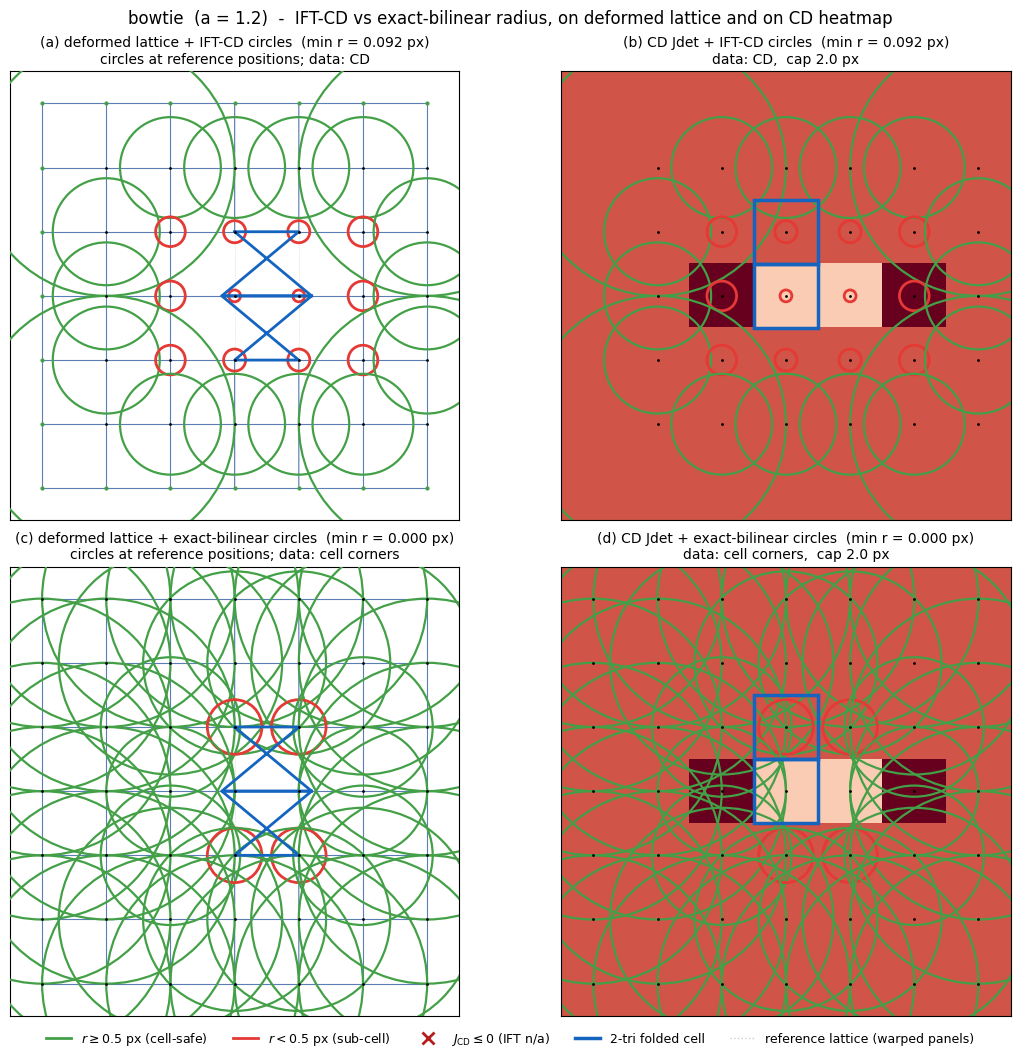

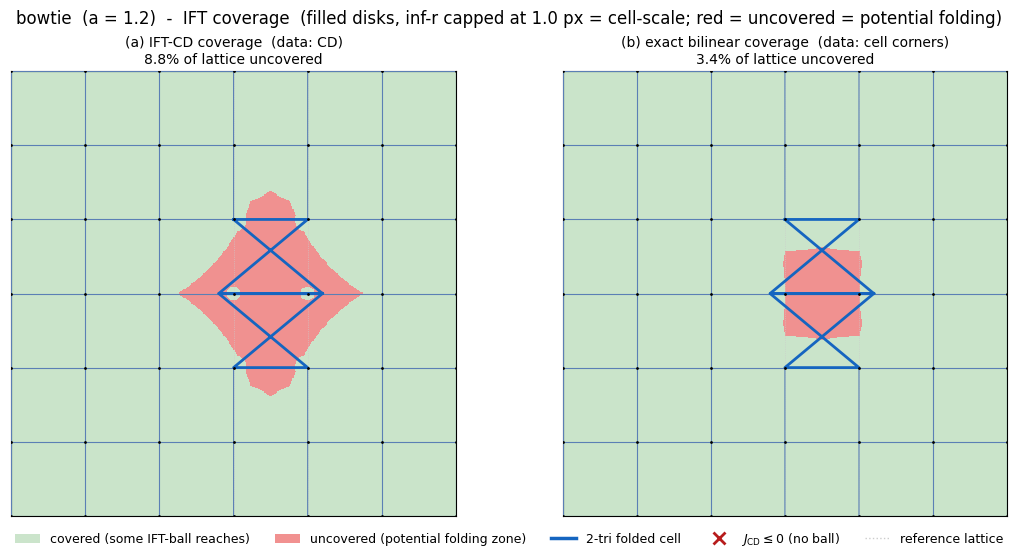

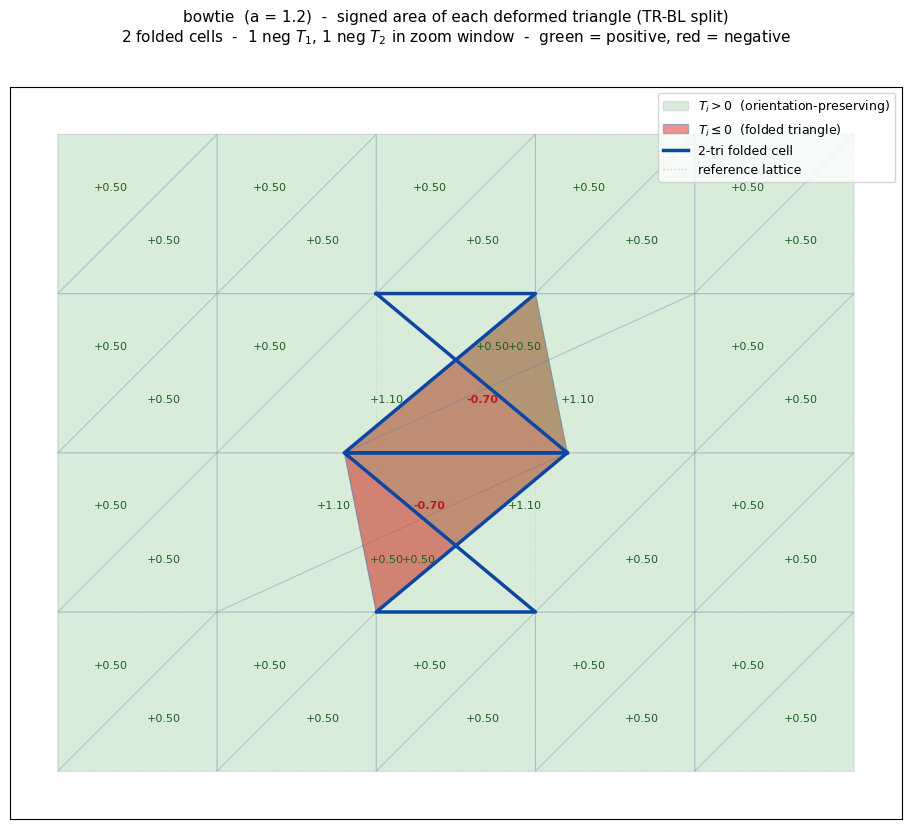


bowtie  (a = 1.2)  -  affected cells (|T - 0.5| > 0.05 on either triangle):
 cell (cy,cx)    T1 (TR,BL,BR)    T2 (TL,BL,TR)   min(T1,T2)   folded?
----------------------------------------------------------------------
   (2,2)               +1.1000          +0.5000      +0.5000        no
   (2,3)               -0.7000          +0.5000      -0.7000       YES
   (2,4)               +1.1000          +0.5000      +0.5000        no
   (3,2)               +0.5000          +1.1000      +0.5000        no
   (3,3)               +0.5000          -0.7000      -0.7000       YES
   (3,4)               +0.5000          +1.1000      +0.5000        no


In [6]:
result_bowtie = plot_case(CASES[1][1], 'bowtie  (a = 1.2)', max_circle=2.0)


## Sub-fold  ($a = 0.4$)

A sanity check at the other end: amplitude small enough that the field stays everywhere orientation-preserving. The bilinear $J(s, t)$ in cell $(3, 3)$ is $0.2 + 0.8 s$ — strictly positive on $[0, 1]^2$, ranging from $0.2$ at the top of the cell to $1.0$ at the bottom. No cell folds, $r_{\rm exact} = +\infty$ everywhere, and the IFT bound should also be comfortably above 1 px.


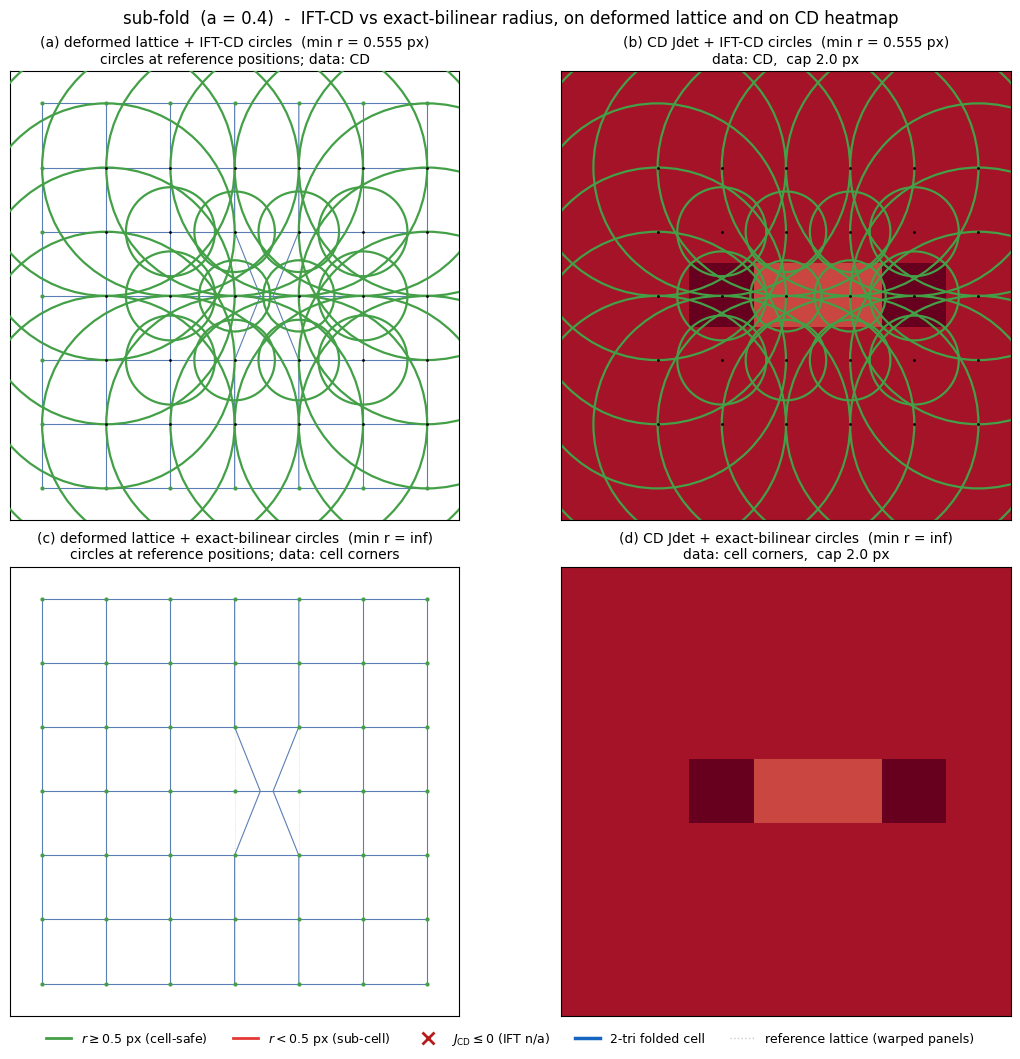

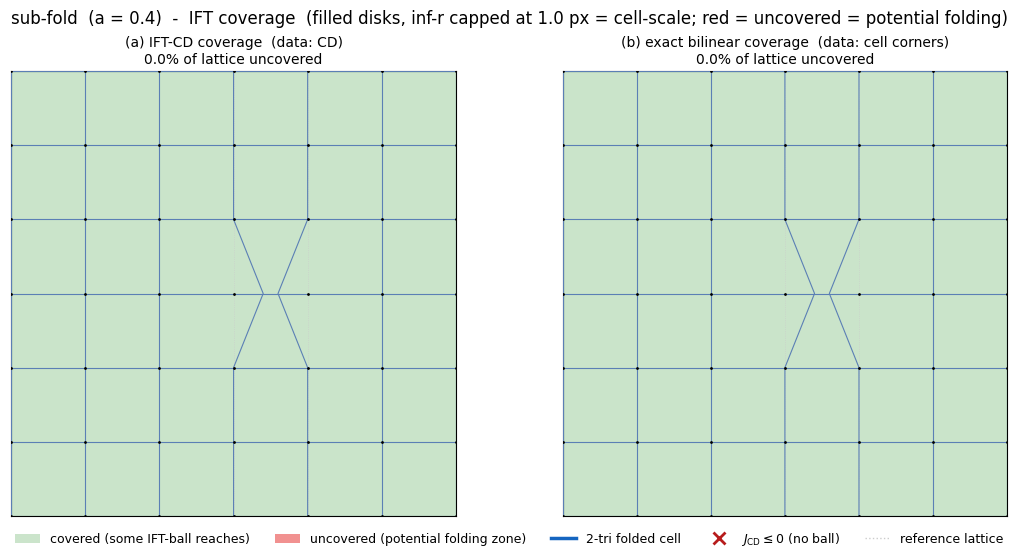

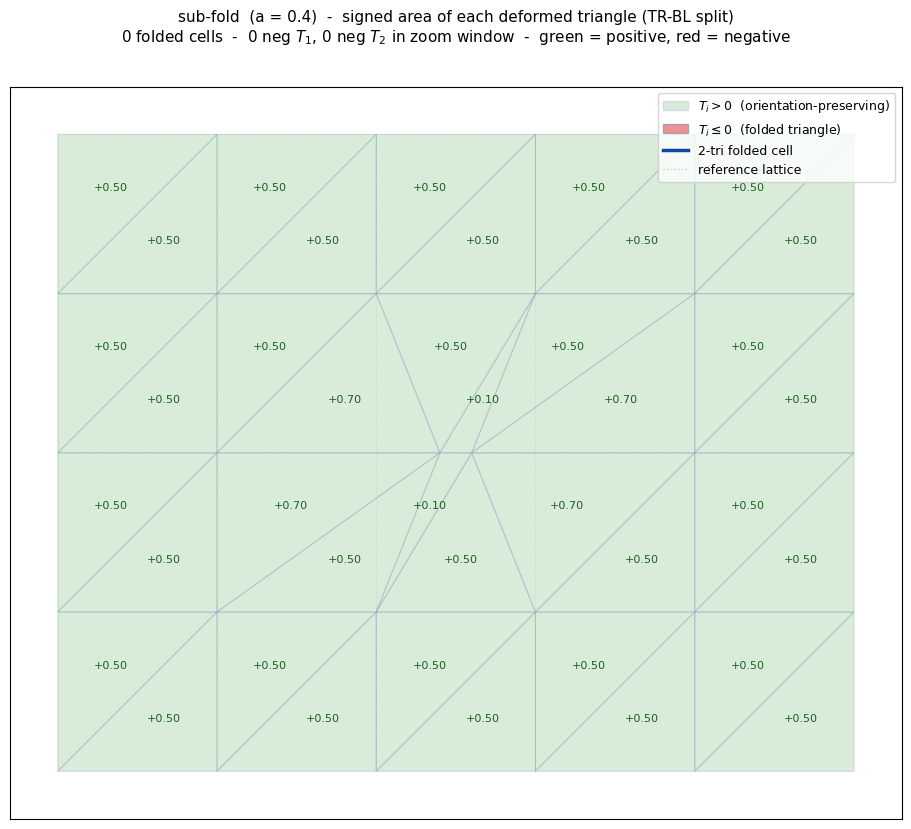


sub-fold  (a = 0.4)  -  affected cells (|T - 0.5| > 0.05 on either triangle):
 cell (cy,cx)    T1 (TR,BL,BR)    T2 (TL,BL,TR)   min(T1,T2)   folded?
----------------------------------------------------------------------
   (2,2)               +0.7000          +0.5000      +0.5000        no
   (2,3)               +0.1000          +0.5000      +0.1000        no
   (2,4)               +0.7000          +0.5000      +0.5000        no
   (3,2)               +0.5000          +0.7000      +0.5000        no
   (3,3)               +0.5000          +0.1000      +0.1000        no
   (3,4)               +0.5000          +0.7000      +0.5000        no


In [7]:
result_sub = plot_case(CASES[0][1], 'sub-fold  (a = 0.4)', max_circle=2.0)


## Severe  ($a = 1.8$)

Push the amplitude further. The bilinear $J$ in cell $(3, 3)$ becomes $-2.6 + 3.6 s$, with the fold region $\{J \le 0\}$ now covering $s \in [0, 0.722]$ — about $72\%$ of the cell. The IFT bound at the bowtie pixel: $\sigma_{\min}(DF) = |1 - 0.9| = 0.1$, $\partial^2 dx/\partial x^2 = -5.4$, $\partial^2 dx/\partial y^2 = -3.6$, $L \approx \sqrt{5.4^2 + 3.6^2} \approx 6.49$, so $r_{\rm IFT} \approx 0.015$ px. Even smaller than the bowtie case — the prediction is "almost no neighbourhood of invertibility at all".


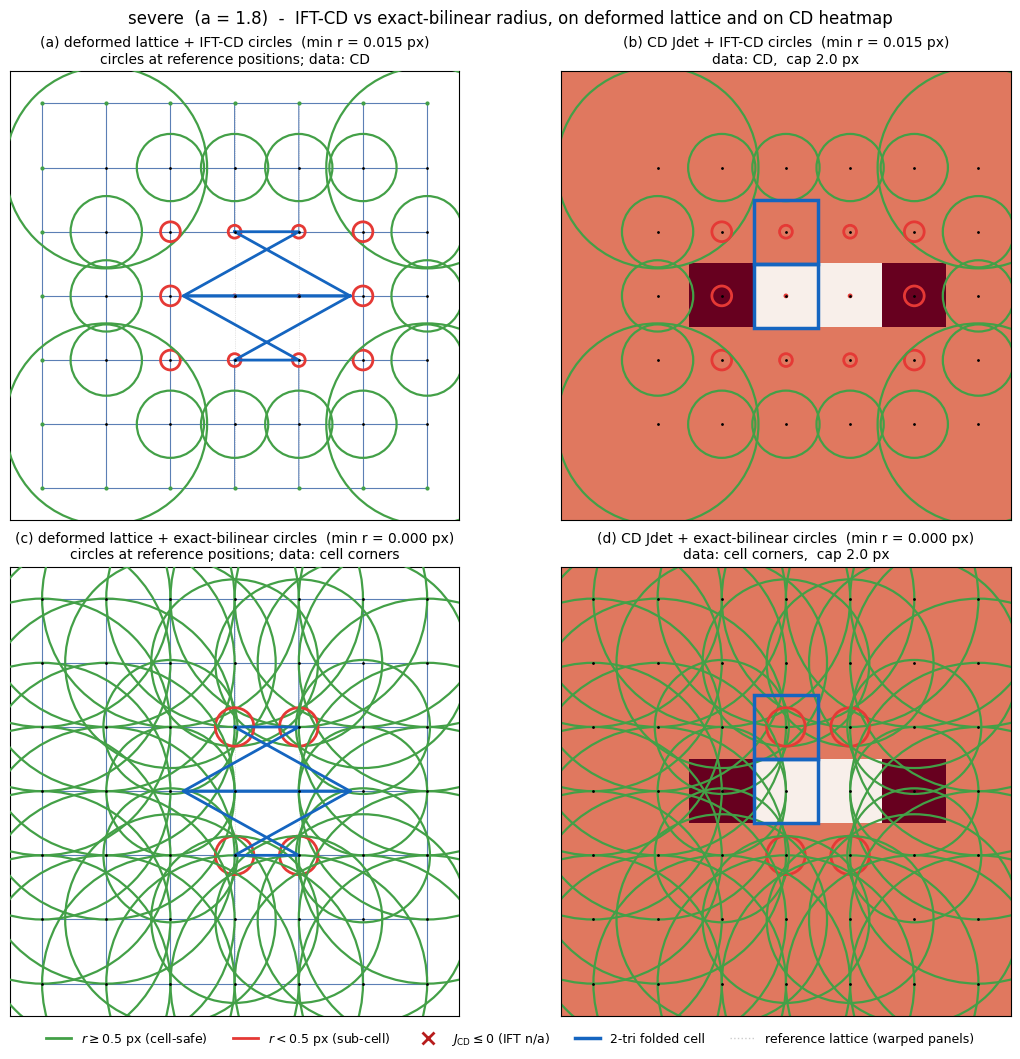

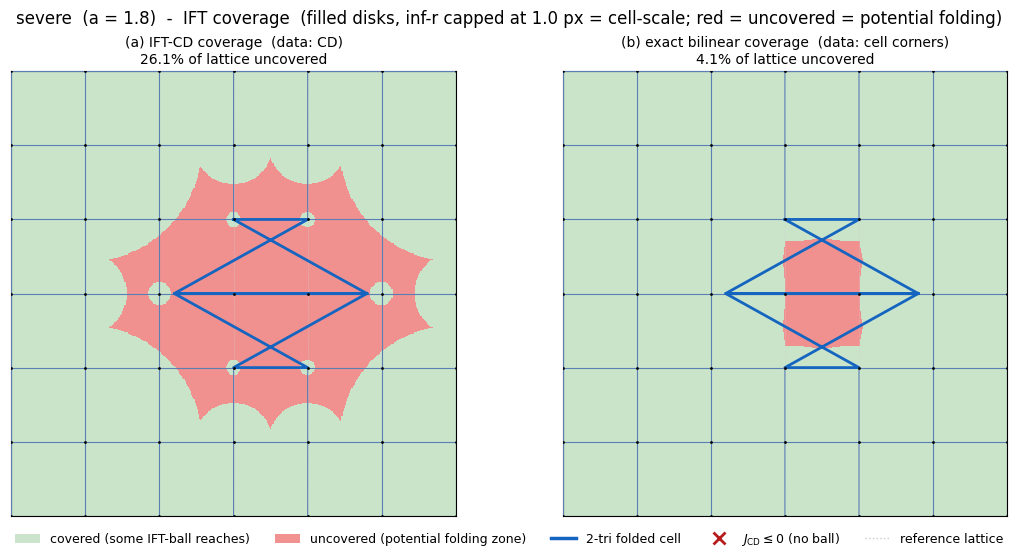

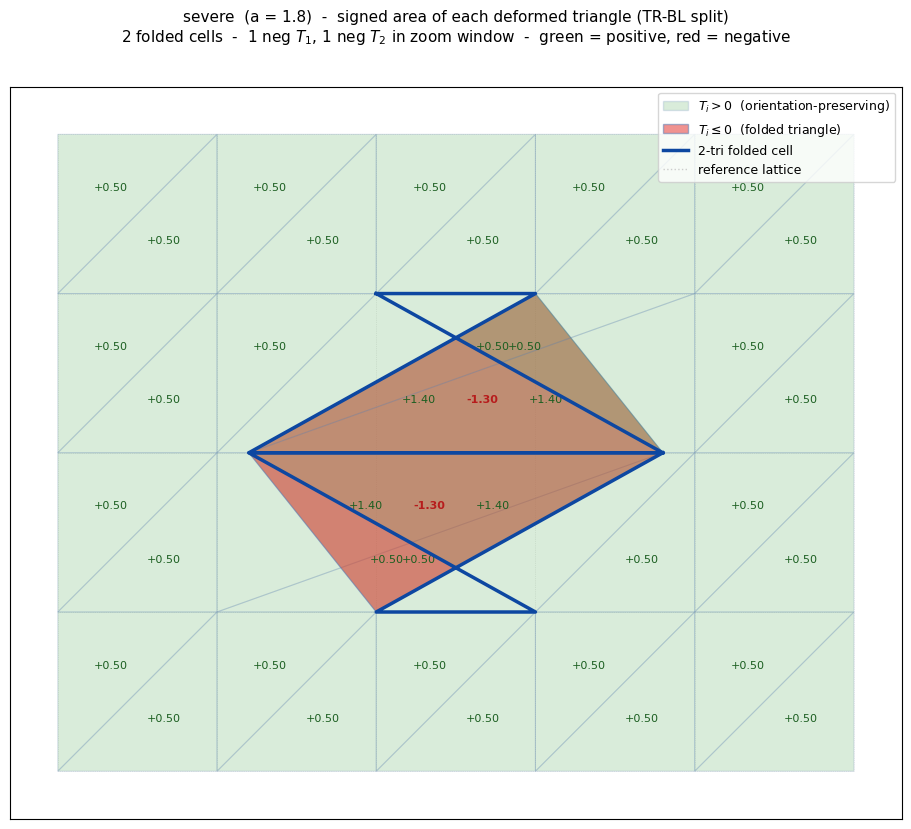


severe  (a = 1.8)  -  affected cells (|T - 0.5| > 0.05 on either triangle):
 cell (cy,cx)    T1 (TR,BL,BR)    T2 (TL,BL,TR)   min(T1,T2)   folded?
----------------------------------------------------------------------
   (2,2)               +1.4000          +0.5000      +0.5000        no
   (2,3)               -1.3000          +0.5000      -1.3000       YES
   (2,4)               +1.4000          +0.5000      +0.5000        no
   (3,2)               +0.5000          +1.4000      +0.5000        no
   (3,3)               +0.5000          -1.3000      -1.3000       YES
   (3,4)               +0.5000          +1.4000      +0.5000        no


In [8]:
result_severe = plot_case(CASES[2][1], 'severe  (a = 1.8)', max_circle=2.0)


## Codomain frame: invertibility radius for $F^{-1}$

Everything above puts the IFT-promised ball at the *reference* (domain) position $x_0$, with the radius $r$ measured in input-space units. That's the right anchor for the forward map $F = \mathrm{id} + \varphi$. The same theorem applied to the **inverse** map $G = F^{-1}$ gives a *different* radius anchored at the **deformed** position $y_0 = F(x_0)$.

The derivation follows the matrix-inverse identity $A^{-1} - B^{-1} = A^{-1}(B - A)B^{-1}$ applied to $A = DF(x_0)$, $B = DF(x_1)$:

$$
\| DG(y_1) - DG(y_0) \| \;\le\; \| DG(y_0) \| \cdot \| DF(x_1) - DF(x_0) \| \cdot \| DG(y_1) \|
\;\le\; \frac{L_{\rm local}}{\sigma_{\min}(DF)^3} \cdot \| y_1 - y_0 \|.
$$

(The third factor $\| y_1 - y_0\|$ comes from $\| x_1 - x_0 \| \le \| DG \| \cdot \| y_1 - y_0 \| = (1/\sigma_{\min}(DF)) \cdot \| y_1 - y_0 \|$.) Combining with $\sigma_{\min}(DG) = 1 / \sigma_{\max}(DF)$ gives the codomain-frame radius:

$$
\boxed{\;r'(y_0) \;=\; \frac{\sigma_{\min}(DF(x_0))^3}{\sigma_{\max}(DF(x_0)) \cdot L_{\rm local}(x_0)}\;}
$$

This is *strictly smaller* than the forward $r = \sigma_{\min}(DF)/L$ at any sub-conditioned pixel, by a factor of $\sigma_{\min}(DF)^2 / \sigma_{\max}(DF)$. Concrete numbers for our three cases:

| case | $\sigma_{\min}(DF)$ | $\sigma_{\max}(DF)$ | $L$ | $r$ (forward) | $r'$ (inverse) | ratio |
|---|---:|---:|---:|---:|---:|---:|
| sub-fold ($a=0.4$) | 0.8 | 1.0 | 1.44 | $0.555$ | $0.355$ | $0.64$ |
| bowtie ($a=1.2$) | 0.4 | 1.0 | 4.33 | $0.0925$ | $0.0148$ | $0.16$ |
| severe ($a=1.8$) | 0.1 | 1.0 | 6.49 | $0.0154$ | $0.000154$ | $0.01$ |

Geometrically: $F^{-1}$ has to "untangle" the spike, so its local stretch grows by roughly $1/\sigma_{\min}(DF)$ in each direction, and its second-derivative scale grows by $1/\sigma_{\min}(DF)^2$ on top of $L$. The bound on its invertibility ball tightens accordingly. As $\sigma_{\min}(DF) \to 0$ (cell collapses to a fold), $r' \to 0$ much faster than $r$.

The figure below shows both views side-by-side per case: same deformed lattice, same folded cells, but the left panel anchors circles at reference positions (forward $r$) while the right anchors at deformed positions (inverse $r'$).


                case  sigma_min(DF)  sigma_max(DF)     max L  min r (fwd)   min r' (inv)    r' / r
----------------------------------------------------------------------------------------------------
            sub-fold         0.8000         1.2000    1.4422       0.5547         0.3550    0.6400
              bowtie         0.4000         1.6000    4.3267       0.0925         0.0148    0.1600
              severe         0.1000         1.9000    6.4900       0.0154         0.0002    0.0100


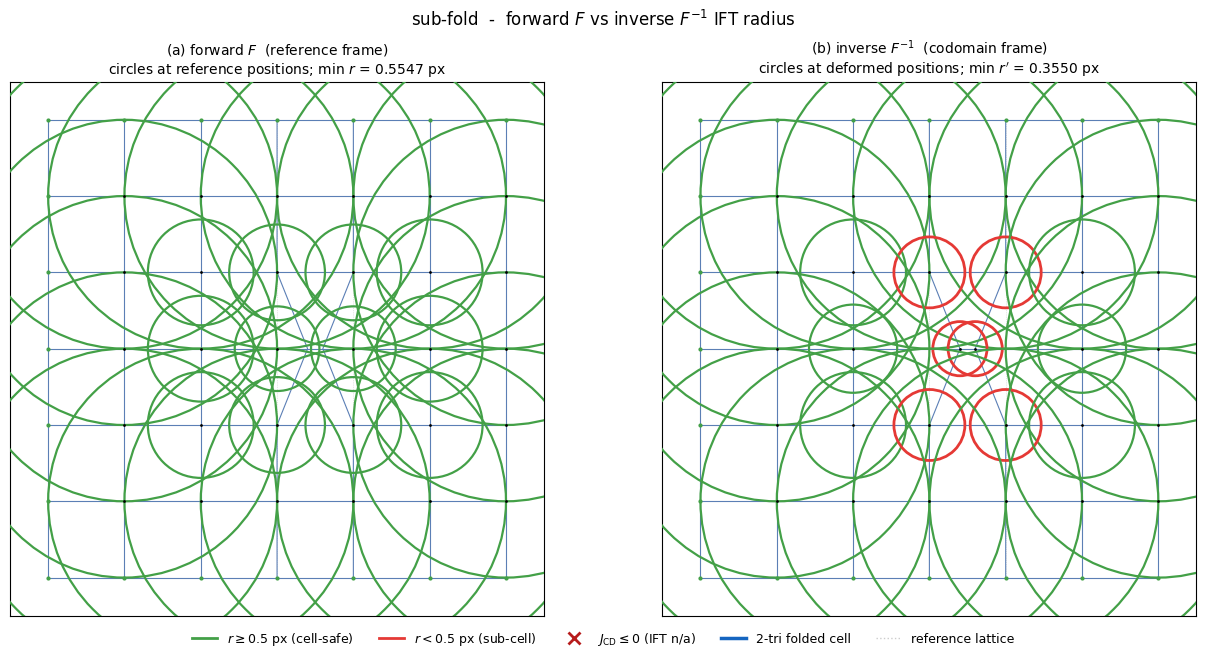

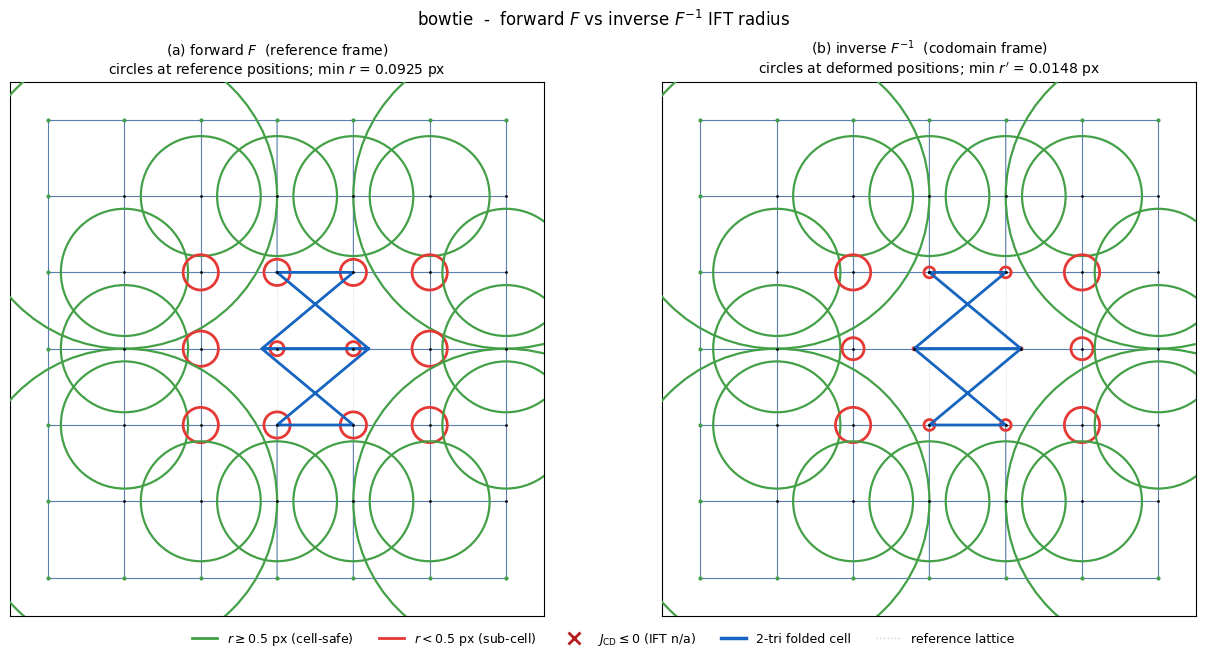

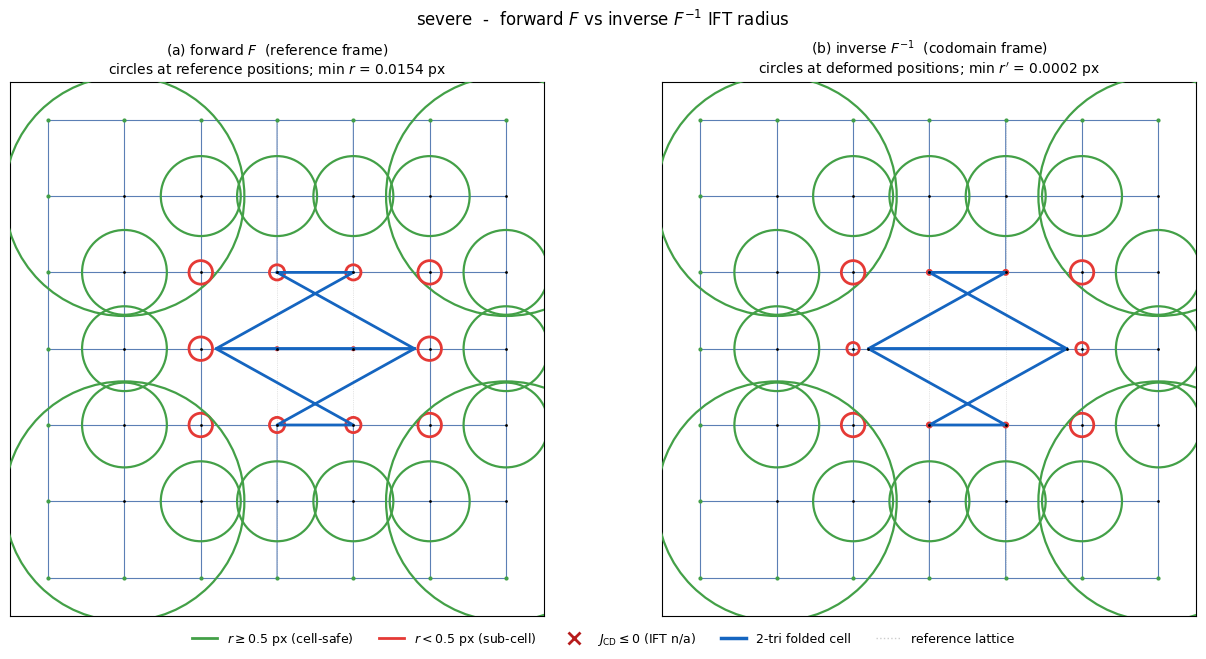

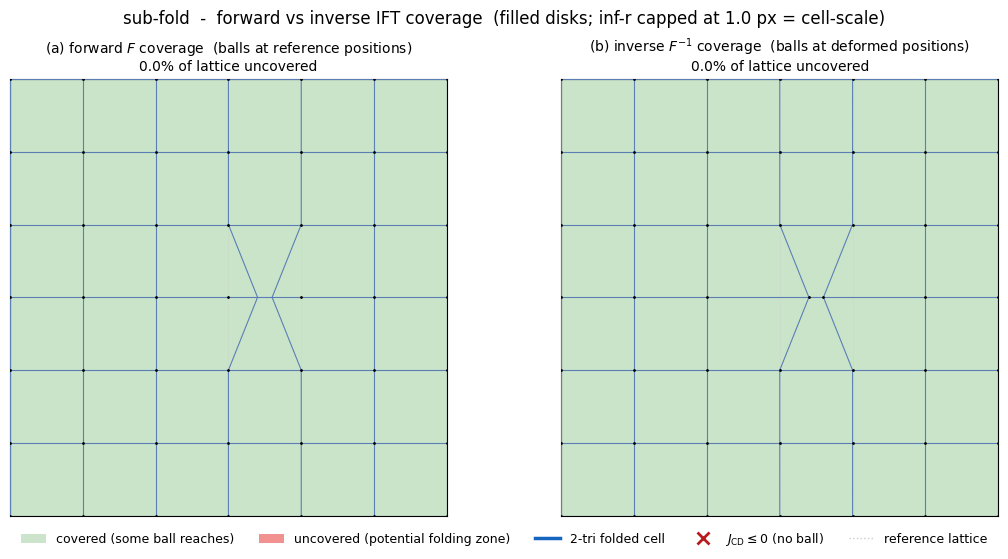

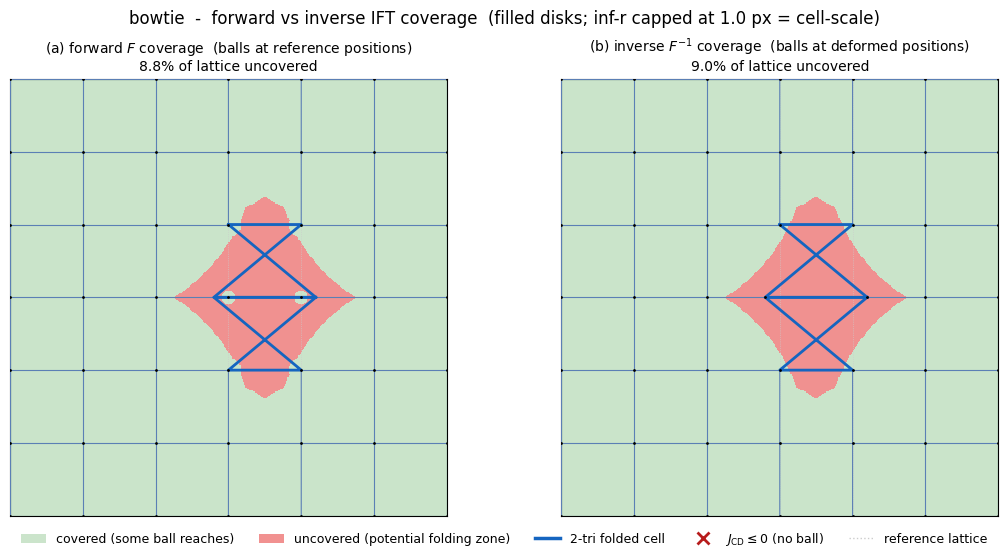

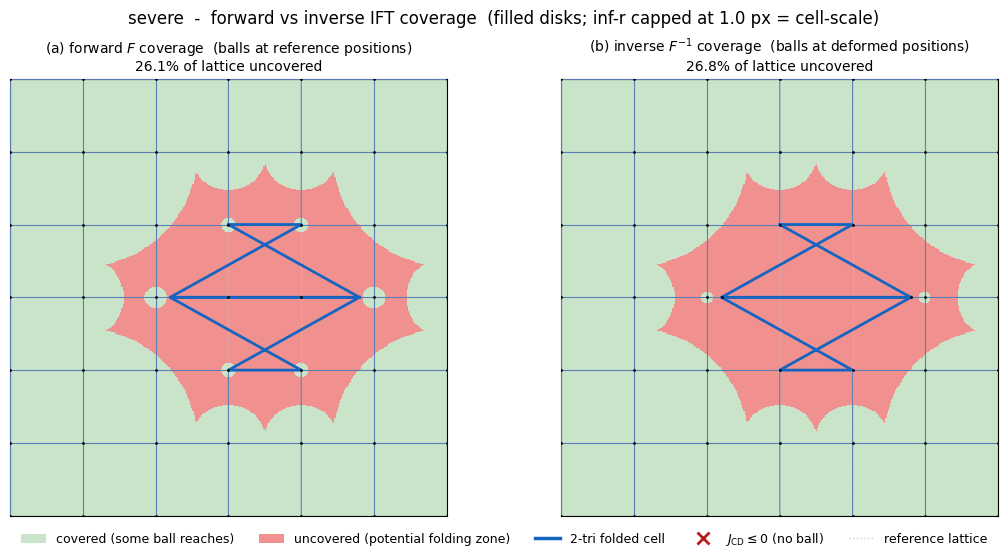

In [9]:
def sigma_min_max_field(DF):
    """Smallest and largest singular values of DF at every pixel."""
    H, W = DF.shape[:2]
    sig_min = np.empty((H, W))
    sig_max = np.empty((H, W))
    for i in range(H):
        for j in range(W):
            svs = np.linalg.svd(DF[i, j], compute_uv=False)
            sig_min[i, j] = svs.min()
            sig_max[i, j] = svs.max()
    return sig_min, sig_max


def inverse_ift_radius_field(phi, neighborhood=1, eps=1e-12):
    """Codomain-frame IFT radius for F^{-1}, indexed by reference pixel.

        r'(y_0) = sigma_min(DF(x_0))^3 / (sigma_max(DF(x_0)) * L_local(x_0))

    where y_0 = F(x_0) is the deformed image of pixel x_0. NaN where J_CD <= 0
    (IFT premise fails); +inf where L_local = 0 (locally affine, bound silent).
    """
    DF = deformation_jacobian_cd(phi)
    sig_min, sig_max = sigma_min_max_field(DF)
    L = lipschitz_constant_local(phi, neighborhood=neighborhood)
    jdet = np.squeeze(jacobian_det2D(phi))
    denom = sig_max * np.maximum(L, eps)
    r_inv = np.where(L > eps, sig_min ** 3 / np.maximum(denom, eps), np.inf)
    r_inv = np.where(jdet > 0, r_inv, np.nan)
    return r_inv


def plot_forward_vs_inverse(phi, name, *, max_circle=2.0, threshold=0.5):
    """Side-by-side circles: forward IFT radius (anchors at reference) vs
    inverse IFT radius (anchors at deformed positions).
    """
    H, W = phi.shape[-2:]
    r_fwd, _, _, _ = ift_radius_field(phi, neighborhood=1)
    r_inv = inverse_ift_radius_field(phi, neighborhood=1)
    folded = folded_cells_mask(phi)
    yy, xx = np.mgrid[:H, :W]
    gx = xx + phi[1]; gy = yy + phi[0]

    def _draw(ax, radius, anchor_x, anchor_y, title):
        for i in range(H):
            ax.plot(xx[i], yy[i], color='#cccccc', lw=0.5, ls=':', zorder=0)
        for j in range(W):
            ax.plot(xx[:, j], yy[:, j], color='#cccccc', lw=0.5, ls=':', zorder=0)
        for i in range(H):
            ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8, zorder=2)
        for j in range(W):
            ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8, zorder=2)
        for (cy, cx) in np.argwhere(folded):
            corners_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            corners_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(corners_x, corners_y, color='#1565c0', lw=2.0, zorder=4)
        for py_idx in range(H):
            for px_idx in range(W):
                r = radius[py_idx, px_idx]
                ax_x = float(anchor_x[py_idx, px_idx])
                ax_y = float(anchor_y[py_idx, px_idx])
                if np.isnan(r):
                    ax.plot(ax_x, ax_y, marker='x', color='#b71c1c',
                            markersize=10, markeredgewidth=2.0, zorder=5)
                    continue
                if not np.isfinite(r):
                    ax.plot(ax_x, ax_y, '.', color='#43a047', markersize=4, zorder=5)
                    continue
                r_draw = float(min(r, max_circle))
                color = '#43a047' if r >= threshold else '#e53935'
                lw = 1.6 if r >= threshold else 2.0
                ax.add_patch(Circle((ax_x, ax_y), r_draw, fill=False,
                                    edgecolor=color, lw=lw, zorder=3))
                ax.plot(ax_x, ax_y, '.', color='black', markersize=2, zorder=5)
        ax.set_aspect('equal'); ax.invert_yaxis()
        _set_grid_extent(ax, H, W)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title, fontsize=10)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), layout='constrained')

    finite_fwd = r_fwd[np.isfinite(r_fwd) & ~np.isnan(r_fwd)]
    fwd_min = f'{finite_fwd.min():.4f} px' if finite_fwd.size else 'inf'
    _draw(axes[0], r_fwd, xx.astype(float), yy.astype(float),
          f'(a) forward $F$  (reference frame)\n'
          f'circles at reference positions; min $r$ = {fwd_min}')

    finite_inv = r_inv[np.isfinite(r_inv) & ~np.isnan(r_inv)]
    inv_min = f'{finite_inv.min():.4f} px' if finite_inv.size else 'inf'
    _draw(axes[1], r_inv, gx, gy,
          f'(b) inverse $F^{{-1}}$  (codomain frame)\n'
          f'circles at deformed positions; min $r\'$ = {inv_min}')

    legend_lines = [
        plt.Line2D([0], [0], color='#43a047', lw=2, label=r'$r \geq 0.5$ px (cell-safe)'),
        plt.Line2D([0], [0], color='#e53935', lw=2, label=r'$r < 0.5$ px (sub-cell)'),
        plt.Line2D([0], [0], marker='x', color='#b71c1c', lw=0, markersize=8,
                   markeredgewidth=2, label=r'$J_{\rm CD} \leq 0$ (IFT n/a)'),
        plt.Line2D([0], [0], color='#1565c0', lw=2.5, label='2-tri folded cell'),
        plt.Line2D([0], [0], color='#cccccc', lw=1, ls=':', label='reference lattice'),
    ]
    fig.legend(handles=legend_lines, loc='outside lower center', ncol=5,
               frameon=False, fontsize=9)
    fig.suptitle(f'{name}  -  forward $F$ vs inverse $F^{{-1}}$ IFT radius', fontsize=12)
    plt.show()


def _coverage_mask_with_anchors(phi, radius, anchors_y, anchors_x, *,
                                 resolution=400, max_r=1.0):
    """Generic coverage mask: True at sample points reachable from any anchor's
    ball. ``anchors_y, anchors_x`` are (H, W) anchor positions; ``radius`` is the
    same-shape array of ball radii. NaN-radius anchors contribute no ball; +inf
    is capped at ``max_r``. Sampling is on the lattice extent [0, W-1] x [0, H-1].
    """
    H, W = phi.shape[-2:]
    yy_grid = np.linspace(0, H - 1, resolution)
    xx_grid = np.linspace(0, W - 1, resolution)
    YY, XX = np.meshgrid(yy_grid, xx_grid, indexing='ij')
    covered = np.zeros_like(YY, dtype=bool)
    for py in range(H):
        for px in range(W):
            r = radius[py, px]
            if np.isnan(r):
                continue
            if not np.isfinite(r):
                r = max_r
            ay = float(anchors_y[py, px])
            ax_ = float(anchors_x[py, px])
            covered |= ((YY - ay) ** 2 + (XX - ax_) ** 2 <= r ** 2)
    return covered


def plot_forward_vs_inverse_coverage(phi, name, *, resolution=400, max_r=1.0):
    """Side-by-side filled-disk coverage maps. Left: forward (balls anchored at
    reference positions). Right: inverse (balls anchored at deformed positions).
    Green = some ball covers, red = uncovered (potential folding zone) — same
    visual idiom as the per-case coverage figures, applied to both frames.
    """
    H, W = phi.shape[-2:]
    r_fwd, _, _, _ = ift_radius_field(phi, neighborhood=1)
    r_inv = inverse_ift_radius_field(phi, neighborhood=1)
    folded = folded_cells_mask(phi)
    yy, xx = np.mgrid[:H, :W]
    gx = xx + phi[1]; gy = yy + phi[0]

    cov_fwd = _coverage_mask_with_anchors(phi, r_fwd,
                                          yy.astype(float), xx.astype(float),
                                          resolution=resolution, max_r=max_r)
    cov_inv = _coverage_mask_with_anchors(phi, r_inv, gy, gx,
                                          resolution=resolution, max_r=max_r)

    def _draw(ax, covered, anchors_y, anchors_x, radius, title):
        rgba = np.zeros((covered.shape[0], covered.shape[1], 4))
        rgba[covered]  = [0.27, 0.63, 0.27, 0.28]
        rgba[~covered] = [0.90, 0.22, 0.21, 0.55]
        ax.imshow(rgba, extent=(0, W - 1, H - 1, 0),
                  origin='upper', aspect='equal', interpolation='nearest', zorder=1)
        for i in range(H):
            ax.plot(xx[i], yy[i], color='#cccccc', lw=0.5, ls=':', zorder=2)
        for j in range(W):
            ax.plot(xx[:, j], yy[:, j], color='#cccccc', lw=0.5, ls=':', zorder=2)
        for i in range(H):
            ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8, zorder=3)
        for j in range(W):
            ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8, zorder=3)
        for (cy, cx) in np.argwhere(folded):
            corners_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            corners_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(corners_x, corners_y, color='#1565c0', lw=2.0, zorder=4)
        for py in range(H):
            for px in range(W):
                r = radius[py, px]
                ay = float(anchors_y[py, px])
                ax_x = float(anchors_x[py, px])
                if np.isnan(r):
                    ax.plot(ax_x, ay, marker='x', color='#b71c1c', markersize=10,
                            markeredgewidth=2.0, zorder=5)
                else:
                    ax.plot(ax_x, ay, '.', color='black', markersize=2, zorder=5)
        uncov_frac = float((~covered).mean())
        ax.set_aspect('equal')
        _set_lattice_extent(ax, H, W)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'{title}\n{uncov_frac * 100:.1f}% of lattice uncovered', fontsize=10)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), layout='constrained')

    _draw(axes[0], cov_fwd, yy.astype(float), xx.astype(float), r_fwd,
          '(a) forward $F$ coverage  (balls at reference positions)')
    _draw(axes[1], cov_inv, gy, gx, r_inv,
          '(b) inverse $F^{-1}$ coverage  (balls at deformed positions)')

    legend_lines = [
        Rectangle((0, 0), 1, 1, fc=(0.27, 0.63, 0.27, 0.28),
                  ec='none', label='covered (some ball reaches)'),
        Rectangle((0, 0), 1, 1, fc=(0.90, 0.22, 0.21, 0.55),
                  ec='none', label='uncovered (potential folding zone)'),
        plt.Line2D([0], [0], color='#1565c0', lw=2.5, label='2-tri folded cell'),
        plt.Line2D([0], [0], marker='x', color='#b71c1c', lw=0, markersize=8,
                   markeredgewidth=2, label=r'$J_{\rm CD} \leq 0$ (no ball)'),
        plt.Line2D([0], [0], color='#cccccc', lw=1, ls=':', label='reference lattice'),
    ]
    fig.legend(handles=legend_lines, loc='outside lower center', ncol=5,
               frameon=False, fontsize=9)
    fig.suptitle(f'{name}  -  forward vs inverse IFT coverage  '
                 f'(filled disks; inf-r capped at {max_r:.1f} px = cell-scale)',
                 fontsize=12)
    plt.show()


# Numerical comparison across cases
print(f'{"case":>20s}  {"sigma_min(DF)":>13s}  {"sigma_max(DF)":>13s}  {"max L":>8s}  '
      f'{"min r (fwd)":>11s}  {"min r\' (inv)":>13s}  {"r\' / r":>8s}')
print('-' * 100)
inv_results = []
for case_name, phi in CASES:
    DF = deformation_jacobian_cd(phi)
    sig_min, sig_max = sigma_min_max_field(DF)
    L = lipschitz_constant_local(phi, neighborhood=1)
    r_fwd_full, _, _, _ = ift_radius_field(phi, neighborhood=1)
    r_inv_full = inverse_ift_radius_field(phi, neighborhood=1)
    fwd_finite = r_fwd_full[np.isfinite(r_fwd_full) & ~np.isnan(r_fwd_full)]
    inv_finite = r_inv_full[np.isfinite(r_inv_full) & ~np.isnan(r_inv_full)]
    r_fwd_min = float(fwd_finite.min()) if fwd_finite.size else float('inf')
    r_inv_min = float(inv_finite.min()) if inv_finite.size else float('inf')
    ratio = r_inv_min / r_fwd_min if r_fwd_min > 0 else float('nan')
    inv_results.append((case_name, sig_min.min(), sig_max.max(), L.max(),
                        r_fwd_min, r_inv_min, ratio))
    print(f'{case_name:>20s}  {sig_min.min():>13.4f}  {sig_max.max():>13.4f}  '
          f'{L.max():>8.4f}  {r_fwd_min:>11.4f}  {r_inv_min:>13.4f}  {ratio:>8.4f}')

# Side-by-side circle figures per case
for case_name, phi in CASES:
    plot_forward_vs_inverse(phi, case_name)

# Side-by-side coverage (filled-disk) figures per case
for case_name, phi in CASES:
    plot_forward_vs_inverse_coverage(phi, case_name)


## Summary

The hypothesis was: *every cell that 2-tri flags as folded should sit on a pixel where the IFT-derived radius collapses to sub-pixel*. The figures lay this out as a 2×2:

|  | (left) deformed lattice | (right) CD Jdet heatmap |
|---|---|---|
| **top:** IFT-CD radius (data: CD) | (a) | (b) |
| **bottom:** exact bilinear radius (data: cell corners) | (c) | (d) |

The two rows are *built from disjoint inputs* — the top row is purely lattice-vertex-difference (CD), the bottom row is purely cell-corner. They agree on every fold cell. The two columns are just two visualisations of the same numbers; (a) vs (b) show the *same* radii on different backgrounds, as do (c) vs (d).

Reading the comparison directly:

- **Panels (a, b) — IFT-CD radius.** A theoretical bound. Conservative: even on the sub-fold case ($a = 0.4$) it shrinks to $r_{\rm IFT} \approx 0.55$ px, sitting just above the 0.5-px threshold, because the second-difference stencil already detects the `+0.4 / −0.4` spike. The bound is loose, but it is *enough*: every fold cell has its anchoring pixel inside a sub-pixel circle.
- **Panels (c, d) — exact bilinear radius.** Tight for the bilinear interpolation model. Goes to $0$ at the bowtie pixels themselves (those pixels sit *inside* the bilinear $\{J \le 0\}$ region under at least one adjacent cell), goes to $+\infty$ on the entire sub-fold field, and matches the $r_{\rm exact}$ formula exactly. This is the same data the 2-tri check uses, repackaged as a continuous-radius field.

### Why the IFT-CD red zone is *bigger* than the exact-bilinear red zone

In the coverage figure, the IFT-CD panel reports a much larger uncovered fraction than the exact-bilinear panel (e.g. $\sim 19\%$ vs $\sim 3\%$ for the severe case). This is not noise — it's the difference between a **bound** and a **ground truth**:

| panel | what red means | tightness |
|---|---|---|
| IFT-CD coverage | "the *Lipschitz bound* is too small to certify invertibility here" | loose — large second-derivative spikes shrink the bound aggressively, so the bound stays silent on regions that are actually fold-free |
| exact-bilinear coverage | "the bilinear $J(s, t)$ *is* $\le 0$ somewhere within $r$ of here" | tight — the boundary of the red region traces the actual $J = 0$ contour |

So for any deformation:
- *exact-bilinear red* $\;\subseteq\;$ *IFT-CD red*. The IFT bound's silence is a strict superset of the actual bilinear fold region; the bound is sound (no missed folds) but not complete (red regions are over-painted).
- *exact-bilinear red* $\;\approx\;$ *2-tri folded cells*. Same input data (4 corner displacements per cell), bilinear vs piecewise-linear interpolation; both agree binary-wise on which cells fold. The bilinear panel is just a continuous-radius rendering of the 2-tri test.

Reading the comparison the other way:

- The cell-corner methods (2-tri, exact-bilinear) are *more specific* — they only flag actual folds and report exactly where the fold lives, with no theoretical-bound padding.
- The CD methods (CD-Jdet alone, or the IFT-CD bound) are *less specific* — the IFT-CD bound over-paints (false-positive folding zones) because it has to be conservative against worst-case curvature. CD-Jdet alone has the opposite failure mode (false negatives — see notebook 13's bowtie). The two CD methods bracket the truth from opposite directions.

The takeaway: **for fold detection, cell-corner methods are sharper.** Both 2-tri and exact-bilinear use the same input as the bilinear interpolation that's actually being applied to the data, so what they flag is what would actually fold. The CD-side IFT bound is useful as an independent confirmation of *where* folding is plausible, but its red zone always exaggerates the real one.

The takeaway is the same one notebook 13 reached, now from a different angle:

> **CD's positive Jdet is not a contradiction with the cell folding.** The IFT only promises invertibility on a ball whose radius depends on $\|D^2\varphi\|$. At a bowtie pixel that radius is sub-pixel; the cell extends well past it; the cell can fold without violating any theorem. CD is technically *correct* about its own input — it's just that its input (the lattice-vertex linearisation alone) is not enough to determine cell-scale invertibility. 2-tri's signed-area check, by sampling the four corners of the actual cell, asks the cell-scale question directly.

The table below collects the per-case numbers.


In [10]:
results = [result_sub, result_bowtie, result_severe]

print(f'{"case":>20s}  {"min J_CD":>10s}  {"min sigma":>10s}  {"max L":>8s}  '
      f'{"min r_IFT":>10s}  {"min r_exact":>11s}  {"n_folded":>8s}')
print('-' * 95)
for r in results:
    finite_ift = r['r_ift'][np.isfinite(r['r_ift']) & ~np.isnan(r['r_ift'])]
    finite_exact = r['r_exact'][np.isfinite(r['r_exact'])]
    min_r_ift_str    = f'{finite_ift.min():>10.4f}' if finite_ift.size else f'{"inf":>10s}'
    min_r_exact_str  = f'{finite_exact.min():>11.4f}' if finite_exact.size else f'{"inf":>11s}'
    print(f'{r["name"]:>20s}  '
          f'{r["jd_cd"].min():>+10.3f}  '
          f'{r["sig"].min():>10.3f}  '
          f'{r["L"].max():>8.3f}  '
          f'{min_r_ift_str}  '
          f'{min_r_exact_str}  '
          f'{int(r["folded"].sum()):>8d}')


                case    min J_CD   min sigma     max L   min r_IFT  min r_exact  n_folded
-----------------------------------------------------------------------------------------------
 sub-fold  (a = 0.4)      +0.800       0.800     1.442      0.5547          inf         0
   bowtie  (a = 1.2)      +0.400       0.400     4.327      0.0925       0.0000         2
   severe  (a = 1.8)      +0.100       0.100     6.490      0.0154       0.0000         2
